In [ ]:
import pandas as pd
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
def read_mnist_images(path):
    """Read MNIST image binary file"""
    with open(path, 'rb') as f:
        magic = np.frombuffer(f.read(4), dtype='>i4')[0]
        n = np.frombuffer(f.read(4), dtype='>i4')[0]
        rows = np.frombuffer(f.read(4), dtype='>i4')[0]
        cols = np.frombuffer(f.read(4), dtype='>i4')[0]
        images = np.frombuffer(f.read(), np.uint8).reshape(n, rows, cols)
    return images

def read_mnist_labels(path):
    """Read MNIST label binary file"""
    with open(path, 'rb') as f:
        magic = np.frombuffer(f.read(4), dtype='>i4')[0]
        n = np.frombuffer(f.read(4), dtype='>i4')[0]
        labels = np.frombuffer(f.read(), np.uint8)
    return labels

In [4]:
# Load training data
train_images = read_mnist_images('./Dataset/MNIST/train-images.idx3-ubyte')
train_labels = read_mnist_labels('./Dataset/MNIST/train-labels.idx1-ubyte')

# Load test data
test_images = read_mnist_images('./Dataset/MNIST/t10k-images.idx3-ubyte')
test_labels = read_mnist_labels('./Dataset/MNIST/t10k-labels.idx1-ubyte')

print(f"Train images shape: {train_images.shape}")  # (60000, 28, 28)
print(f"Train labels shape: {train_labels.shape}")  # (60000,)
print(f"Test images shape: {test_images.shape}")    # (10000, 28, 28)
print(f"Test labels shape: {test_labels.shape}")  

Train images shape: (60000, 28, 28)
Train labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


In [5]:
train_images = train_images / 255.0
test_images = test_images / 255.0

In [6]:
train_images = train_images.reshape(-1, 28*28)
test_images = test_images.reshape(-1, 28*28)

In [7]:
train_images.shape

(60000, 784)

In [6]:
test_images.shape  # (60000, 784)

(10000, 784)

In [8]:
print(train_images[0].min(), train_images[0].max())

0.0 1.0


In [7]:
X = train_images
y = train_labels

In [8]:
# Ensure data is 2D before training
X_reshaped = X.reshape(X.shape[0], -1)  # Flatten to (60000, 784)
test_images_reshaped = test_images.reshape(test_images.shape[0], -1)  # Flatten to (10000, 784)

# Train the model
model = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=20, random_state=42)
model.fit(X_reshaped, y)

# Test on test set
y_pred = model.predict(test_images_reshaped)

# Evaluate
accuracy = accuracy_score(test_labels, y_pred)
precision = precision_score(test_labels, y_pred, average='weighted')
recall = recall_score(test_labels, y_pred, average='weighted')
f1 = f1_score(test_labels, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

/Users/arminsiavashi/Desktop/DCA/CPU-Vs-FPGA/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/arminsiavashi/Desktop/DCA/CPU-Vs-FPGA/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/arminsiavashi/Desktop/DCA/CPU-Vs-FPGA/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Accuracy: 0.9769
Precision: 0.9770
Recall: 0.9769
F1-Score: 0.9769


/Users/arminsiavashi/Desktop/DCA/CPU-Vs-FPGA/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/arminsiavashi/Desktop/DCA/CPU-Vs-FPGA/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/arminsiavashi/Desktop/DCA/CPU-Vs-FPGA/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/arminsiavashi/Desktop/DCA/CPU-Vs-FPGA/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


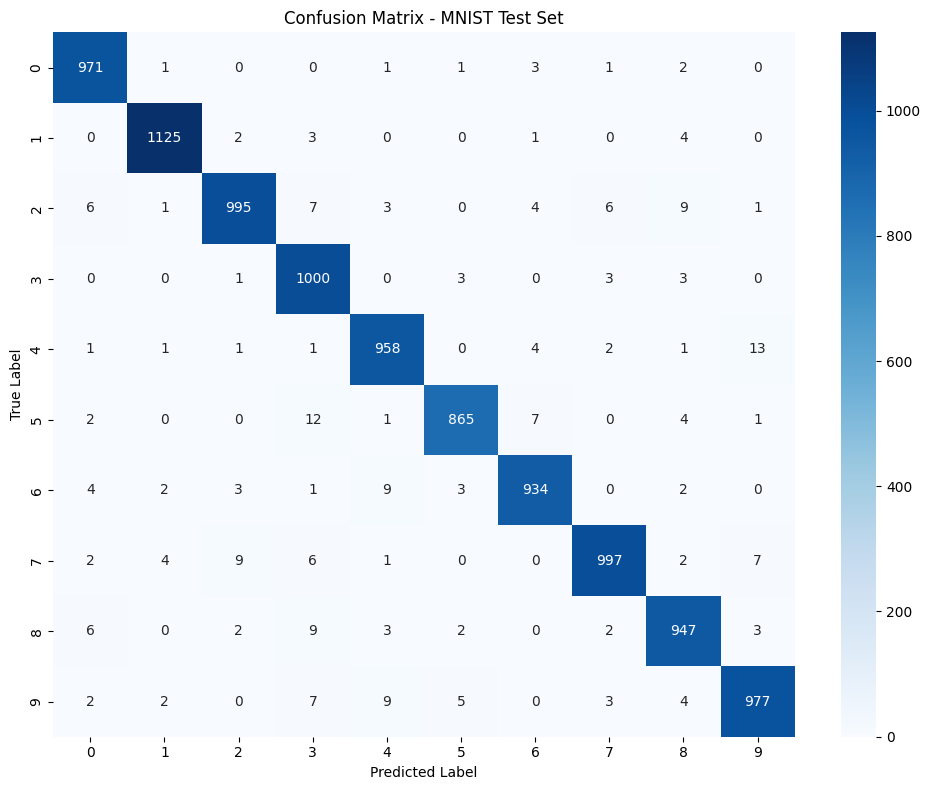


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.96      0.97      1032
           3       0.96      0.99      0.97      1010
           4       0.97      0.98      0.97       982
           5       0.98      0.97      0.98       892
           6       0.98      0.97      0.98       958
           7       0.98      0.97      0.98      1028
           8       0.97      0.97      0.97       974
           9       0.98      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [9]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Confusion Matrix
cm = confusion_matrix(test_labels, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - MNIST Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# 2. Classification Report
print("\nClassification Report:")
print(classification_report(test_labels, y_pred))

In [10]:
# Check for overfitting: Compare train vs test accuracy
from sklearn.metrics import accuracy_score

train_pred = model.predict(X_reshaped)
train_accuracy = accuracy_score(y, train_pred)

print(f"\n=== Model Performance Comparison ===")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy:     {accuracy:.4f}")
print(f"Difference:        {abs(train_accuracy - accuracy):.4f}")

if abs(train_accuracy - accuracy) < 0.05:
    print("✓ No significant overfitting detected")
else:
    print("⚠ Possible overfitting - gap between train and test accuracy")


=== Model Performance Comparison ===
Training Accuracy: 0.9990
Test Accuracy:     0.9769
Difference:        0.0222
✓ No significant overfitting detected


/Users/arminsiavashi/Desktop/DCA/CPU-Vs-FPGA/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/arminsiavashi/Desktop/DCA/CPU-Vs-FPGA/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/arminsiavashi/Desktop/DCA/CPU-Vs-FPGA/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [11]:
# 3. Cross-Validation to ensure robustness
from sklearn.model_selection import cross_val_score

print("\n=== K-Fold Cross-Validation ===")
cv_scores = cross_val_score(MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=20, random_state=42), 
                             X_reshaped, y, cv=5, scoring='accuracy')

print(f"CV Fold Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Std Deviation:    {cv_scores.std():.4f}")

if cv_scores.std() < 0.02:
    print("✓ Model is stable across different folds")
else:
    print("⚠ High variance across folds - model may be unstable")


=== K-Fold Cross-Validation ===


/Users/arminsiavashi/Desktop/DCA/CPU-Vs-FPGA/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/arminsiavashi/Desktop/DCA/CPU-Vs-FPGA/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/arminsiavashi/Desktop/DCA/CPU-Vs-FPGA/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/arminsiavashi/Desktop/DCA/CPU-Vs-FPGA/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/arminsiavashi/Desktop/DCA/CPU-Vs-FPGA/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/arminsiavashi/Desktop/DCA/CPU

CV Fold Scores: [0.976      0.97191667 0.97241667 0.97025    0.9735    ]
Mean CV Accuracy: 0.9728
Std Deviation:    0.0019
✓ Model is stable across different folds


/Users/arminsiavashi/Desktop/DCA/CPU-Vs-FPGA/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/arminsiavashi/Desktop/DCA/CPU-Vs-FPGA/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/arminsiavashi/Desktop/DCA/CPU-Vs-FPGA/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/arminsiavashi/Desktop/DCA/CPU-Vs-FPGA/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [12]:
# 4. Per-digit accuracy analysis
print("\n=== Per-Digit Accuracy ===")
for digit in range(10):
    mask = test_labels == digit
    digit_accuracy = accuracy_score(test_labels[mask], y_pred[mask])
    count = mask.sum()
    print(f"Digit {digit}: {digit_accuracy:.4f} (n={count})")


=== Per-Digit Accuracy ===
Digit 0: 0.9908 (n=980)
Digit 1: 0.9912 (n=1135)
Digit 2: 0.9641 (n=1032)
Digit 3: 0.9901 (n=1010)
Digit 4: 0.9756 (n=982)
Digit 5: 0.9697 (n=892)
Digit 6: 0.9749 (n=958)
Digit 7: 0.9698 (n=1028)
Digit 8: 0.9723 (n=974)
Digit 9: 0.9683 (n=1009)
